In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec

In [ ]:
#pip install gensim


In [ ]:
english_texts = [
    "the weather is nice today",
    "i need water",
    "where is station",
    "hello",
    "good morning",
    "good evening",
    "i am hungry",
    "i love you",
    "the cat is sleeping",
    "learning AI is fun"
]

german_texts = [
    "das wetter ist heute schön",
    "ich brauche wasser",
    "wo ist der bahnhof",
    "hallo",
    "guten morgen",
    "guten abend",
    "ich habe hunger",
    "ich liebe dich",
    "die katze schläft",
    "ki lernen macht spaß"
]

In [ ]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(english_texts)
X_seq = tokenizer.texts_to_sequences(english_texts)
#sequences = tokenizer.texts_to_sequences(english_texts)

print("word Index: ")
print(tokenizer.word_index)

print("\n Sequences: ")
print(X_seq)
# lengths = [len(seq) for seq in sequences]
# print(lengths)

max_length = 5

X = pad_sequences(
    X_seq,
    maxlen = max_length,
    padding = "post"
)

print(X)


word Index: 
{'is': 1, 'i': 2, 'the': 3, 'good': 4, 'weather': 5, 'nice': 6, 'today': 7, 'need': 8, 'water': 9, 'where': 10, 'station': 11, 'hello': 12, 'morning': 13, 'evening': 14, 'am': 15, 'hungry': 16, 'love': 17, 'you': 18, 'cat': 19, 'sleeping': 20, 'learning': 21, 'ai': 22, 'fun': 23}

 Sequences: 
[[3, 5, 1, 6, 7], [2, 8, 9], [10, 1, 11], [12], [4, 13], [4, 14], [2, 15, 16], [2, 17, 18], [3, 19, 1, 20], [21, 22, 1, 23]]
[[ 3  5  1  6  7]
 [ 2  8  9  0  0]
 [10  1 11  0  0]
 [12  0  0  0  0]
 [ 4 13  0  0  0]
 [ 4 14  0  0  0]
 [ 2 15 16  0  0]
 [ 2 17 18  0  0]
 [ 3 19  1 20  0]
 [21 22  1 23  0]]


In [ ]:
#German
tokenizer1 = Tokenizer()
tokenizer1.fit_on_texts(german_texts)

#sequences1 = tokenizer.texts_to_sequences(german_texts)
Y_seq = tokenizer1.texts_to_sequences(german_texts)

print("word Index: ")
print(tokenizer1.word_index)

print("\n Sequences: ")
print(Y_seq)
# lengths = [len(seq) for seq in sequences]
# print(lengths)


max_length = 5

Y = pad_sequences(
    Y_seq,
    maxlen = max_length,
    padding = "post"
)

print(Y)

word Index: 
{'ich': 1, 'ist': 2, 'guten': 3, 'das': 4, 'wetter': 5, 'heute': 6, 'schön': 7, 'brauche': 8, 'wasser': 9, 'wo': 10, 'der': 11, 'bahnhof': 12, 'hallo': 13, 'morgen': 14, 'abend': 15, 'habe': 16, 'hunger': 17, 'liebe': 18, 'dich': 19, 'die': 20, 'katze': 21, 'schläft': 22, 'ki': 23, 'lernen': 24, 'macht': 25, 'spaß': 26}

 Sequences: 
[[4, 5, 2, 6, 7], [1, 8, 9], [10, 2, 11, 12], [13], [3, 14], [3, 15], [1, 16, 17], [1, 18, 19], [20, 21, 22], [23, 24, 25, 26]]
[[ 4  5  2  6  7]
 [ 1  8  9  0  0]
 [10  2 11 12  0]
 [13  0  0  0  0]
 [ 3 14  0  0  0]
 [ 3 15  0  0  0]
 [ 1 16 17  0  0]
 [ 1 18 19  0  0]
 [20 21 22  0  0]
 [23 24 25 26  0]]


In [ ]:
model = Sequential()

model.add(Embedding(
    input_dim = len(tokenizer.word_index) + 1,
    output_dim = 8,
    input_length = max_length
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.add(SimpleRNN(32, return_sequences=True))
model.add(SimpleRNN(16))
model.add(Dense(5, activation = "sigmoid"))

In [ ]:
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

In [ ]:
#reshpae x in terms of y
#X = X.reshape((X.shape[0], X.shape[1], 1))

In [ ]:
print(X.shape)
print(Y.shape)

(10, 5)
(10, 5)


In [ ]:
history = model.fit(
    X,
    Y,
    epochs = 200,
    verbose = 1
)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.4000 - loss: 0.4539
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5000 - loss: 0.2562
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5000 - loss: 0.0557
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5000 - loss: -0.1498
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4000 - loss: -0.3623
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4000 - loss: -0.5836
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4000 - loss: -0.8152
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4000 - loss: -1.0584
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4000 - loss: -1.3142
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4000 - loss: -1.5831
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4000 - loss: -1.8655
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.400

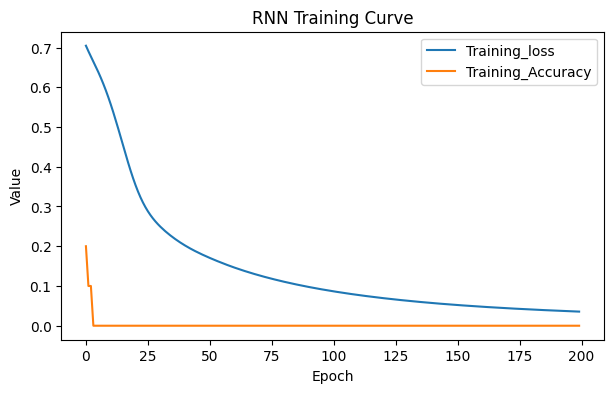

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize = (7,4))
plt.plot(history.history['loss'], label='Training_loss')
plt.plot(history.history['accuracy'], label='Training_Accuracy')
plt.title("RNN Training Curve")
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.show()

In [ ]:
#output
reverse_de_word_index = {
    value: key for key, value in tokenizer1.word_index.items()
}

#print(reverse_de_word_index)
def translate_sentence(model, sent):
  #tokenizer3 = Tokenizer()
  #tokenizer3.fit_on_texts(sent)
  O_seq = tokenizer.texts_to_sequences([sent])
  #sequences = tokenizer.texts_to_sequences(english_texts)

  #print("word Index: ")
  #print(tokenizer.word_index)

  #print("\n Sequences: ")
  #print(O_seq)

# lengths = [len(seq) for seq in sequences]
# print(lengths)

  max_length = 5

  O = pad_sequences(
    O_seq,
    maxlen = max_length,
    padding = "post"
  )

  prediction = model.predict(O)
  predicted_ids = np.argmax(prediction[0], axis=1)

  de_sent = []
  for i in predicted_ids:
    if i != 0:
      de_sent.append(
          reverse_de_word_index.get(i,'')
      )
  return " ".join(de_sent)

  #print(prediction)

sent = "I love you"
print("your sentence:")
print(sent)

print("Translation:")
print(translate_sentence(model, sent))

your sentence:
I love you
Translation:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


AxisError: axis 1 is out of bounds for array of dimension 1